In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\user\Desktop\jupyter\ml\Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
X = df.drop(['Id', 'Species'], axis = 1)
y = df['Species']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=0
)

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from sklearn.neighbors import KNeighborsClassifier

k = 3

knn = KNeighborsClassifier(
    n_neighbors = k,
    metric='euclidean'
)

knn.fit(X_train, y_train)

print(f'Accuracy pf KNN classifier on training set: {knn.score(X_train, y_train)}')

print(f'Accuracy pf KNN classifier on test set: {knn.score(X_test, y_test)}')

Accuracy pf KNN classifier on training set: 0.9732142857142857
Accuracy pf KNN classifier on test set: 0.9736842105263158


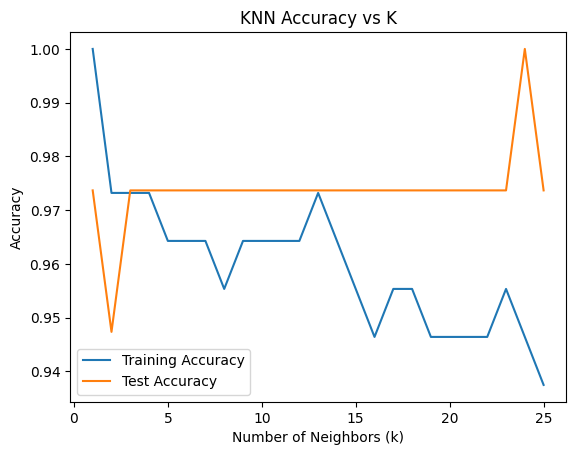

In [11]:
import numpy as np

k_values = range(1, 26)
train_accuracy = []
test_accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    train_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

plt.figure()
plt.plot(k_values, train_accuracy, label='Training Accuracy')
plt.plot(k_values, test_accuracy, label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')
plt.legend()
plt.show()

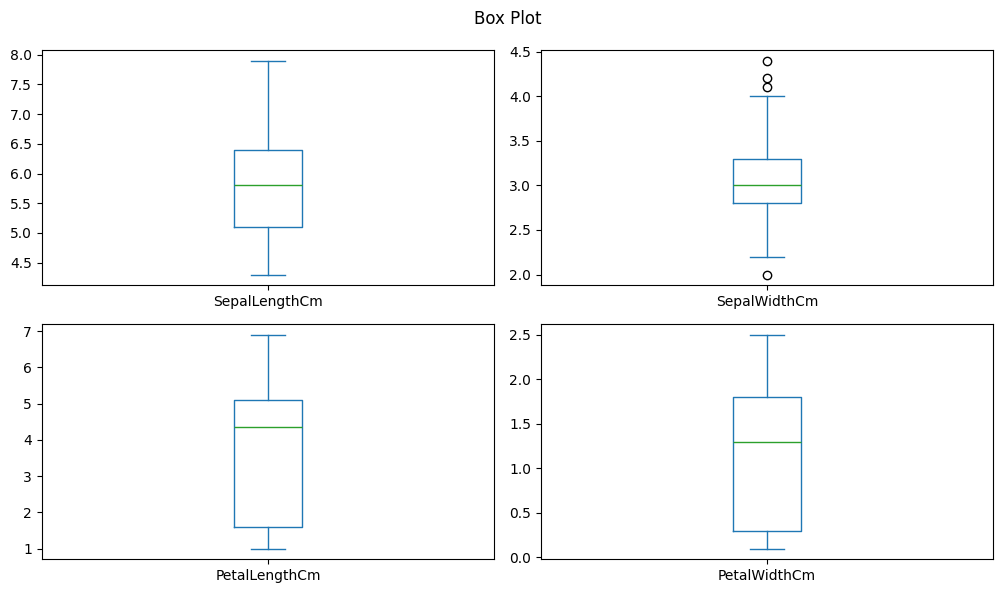

In [12]:
import matplotlib.pyplot as plt

df.drop(['Id', 'Species'], axis=1).plot(
    kind='box',
    subplots=True,
    layout=(2, 2),
    figsize=(10, 6),
    title='Box Plot'
)

plt.tight_layout()
plt.show()

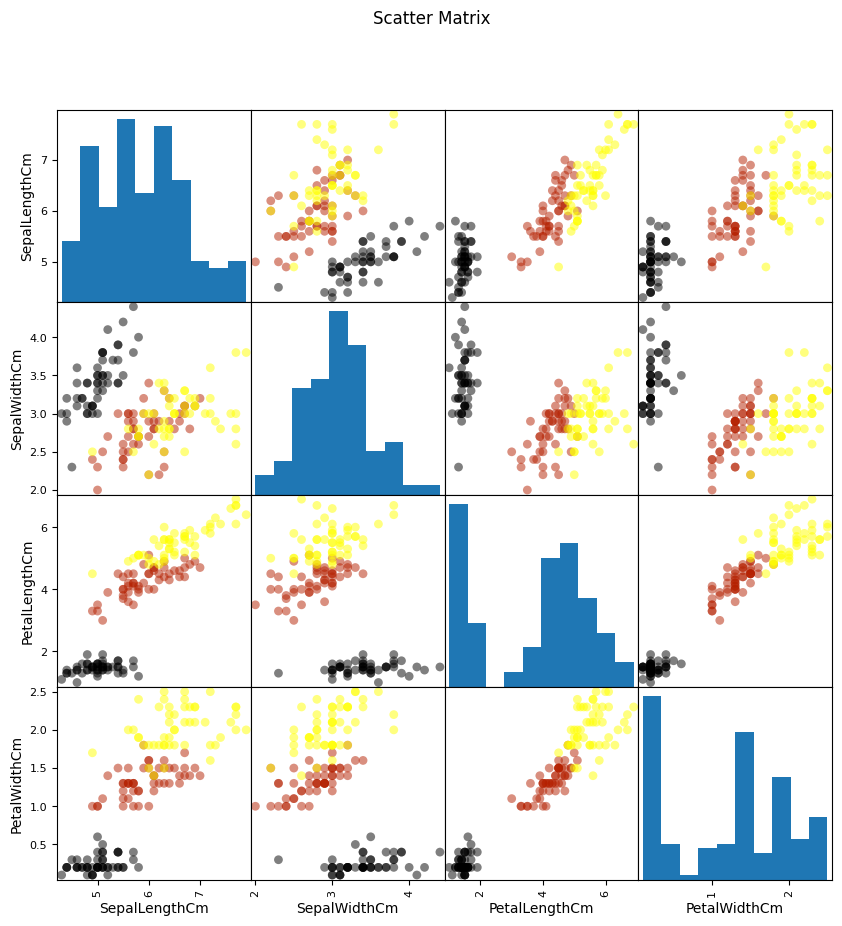

In [13]:
from matplotlib import pyplot
import pandas as pd

feature_names = ['SepalLengthCm', 'SepalWidthCm',
                 'PetalLengthCm', 'PetalWidthCm']

X_vis = df[feature_names]
y_vis = df['Species'].astype('category').cat.codes

cmap = pyplot.get_cmap('gnuplot')

pd.plotting.scatter_matrix(
    X_vis,
    c=y_vis,
    marker='o',
    s=40,
    figsize=(10, 10),
    cmap=cmap
)

plt.suptitle('Scatter Matrix')
plt.show()

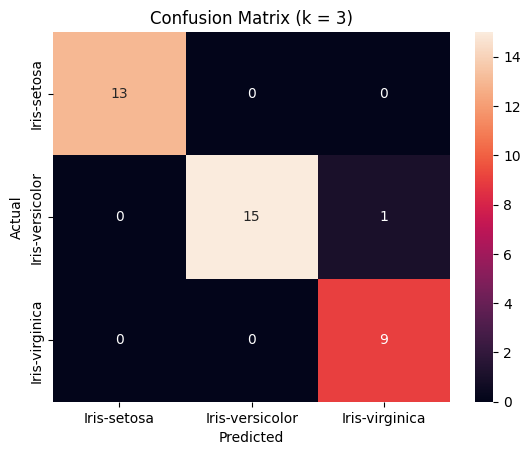

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=knn.classes_,
            yticklabels=knn.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (k = 3)')
plt.show()